In [1]:
# ============================================================
#   Auto‑Encoder Similarity Notebook for One Shape Folder
# ============================================================

# 0️⃣ Install / import packages (versions pinned for Colab)
!pip install -q "tensorflow==2.18.0" "pandas==2.1.4" "plotly>=5.19.0,<6" pillow scikit-learn

import os, io, base64, random, math
from pathlib import Path

import numpy as np
import plotly.express as px
import tensorflow as tf
from tensorflow.keras import layers, models
from PIL import Image
from sklearn.decomposition import PCA
from IPython.display import HTML, display


In [68]:
#@title 1️⃣ Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [69]:

#@title 2️⃣ FIXED Settings for Shape Similarity
SHAPES_ROOT = "/content/drive/MyDrive/shapes"

shape_folder   = "shape3"   #@param ["shape3","shape4","shape5","shape6"]
batch_size     = 32         #@param {type:"integer"}
epochs         = 60         #@param {type:"integer"}  # Reduced epochs
beta           = 0.05       #@param {type:"number"}   # MUCH lower β for shape focus
learning_rate  = 0.001      #@param {type:"number"}   # Higher LR
latent_dim     = 32         #@param {type:"integer"}  # Smaller latent space
plot_latent_2D = True       #@param {type:"boolean"}

shape_path = Path(SHAPES_ROOT) / shape_folder
assert shape_path.is_dir(), f"{shape_path} not found"

print(f"🔧 SHAPE-FOCUSED VAE SETTINGS:")
print(f"▶ β parameter: {beta} (almost pure autoencoder)")
print(f"▶ Latent dimensions: {latent_dim} (forces shape compression)")
print(f"▶ Learning rate: {learning_rate} (faster convergence)")

🔧 SHAPE-FOCUSED VAE SETTINGS:
▶ β parameter: 0.05 (almost pure autoencoder)
▶ Latent dimensions: 32 (forces shape compression)
▶ Learning rate: 0.001 (faster convergence)


In [70]:
#@title 3️⃣ FIXED Load images (NO pixel inversion)
def load_png_fixed(path):
    """Load without pixel inversion - stroke=white(1), background=black(0)"""
    img = Image.open(path).convert("L")
    arr = np.array(img, dtype=np.float32) / 255.0  # NO INVERSION!
    return arr[..., None]

all_pngs = sorted([p for p in shape_path.iterdir() if p.suffix.lower()==".png"])
assert all_pngs, "No PNG images found."

ref_name = f"original{shape_folder[-1]}.png"
ref_path = shape_path / ref_name
assert ref_path.exists(), f"{ref_name} missing"
drawing_paths = [p for p in all_pngs if p.name != ref_name]

print(f"▶ Loading images with CORRECT pixel values...")
ref_img = load_png_fixed(ref_path)
x_imgs = np.stack([load_png_fixed(p) for p in drawing_paths], axis=0)

print(f"✅ Loaded {len(drawing_paths)} drawings (+1 reference)")
print(f"📊 Pixel values: stroke=white(1.0), background=black(0.0)")
print(f"📐 Reference range: {ref_img.min():.3f} to {ref_img.max():.3f}")
print("Tensor shape:", x_imgs.shape)

▶ Loading images with CORRECT pixel values...
✅ Loaded 897 drawings (+1 reference)
📊 Pixel values: stroke=white(1.0), background=black(0.0)
📐 Reference range: 0.000 to 1.000
Tensor shape: (897, 200, 200, 1)


In [71]:
#@title 4️⃣ FIXED Shape-Focused VAE Architecture
import tensorflow as tf
from tensorflow.keras import layers, models

# ------------------------------------------------------------------
img_h = 200
img_w = 200
# latent_dim = 32 (defined in cell 2)
# ------------------------------------------------------------------

def build_shape_encoder():
    """Encoder focused purely on geometric shape features"""
    inp = layers.Input(shape=(img_h, img_w, 1))

    # Focused edge detection
    x = layers.Conv2D(16, 3, activation="relu", padding="same")(inp)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.MaxPool2D(2)(x)                         # 100×100

    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPool2D(2)(x)                         # 50×50

    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.MaxPool2D(2)(x)                         # 25×25

    # Focus on shape, not position
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)                 # Stabilize training

    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_logv = layers.Dense(latent_dim, name="z_logv")(x)

    return models.Model(inp, [z_mean, z_logv], name="shape_encoder")

def build_shape_decoder():
    """Minimal decoder - focus is on encoding quality"""
    dec_in = layers.Input(shape=(latent_dim,))

    y = layers.Dense(25 * 25 * 64, activation="relu")(dec_in)
    y = layers.Reshape((25, 25, 64))(y)

    y = layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(y)  # 50×50
    y = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(y)  # 100×100
    y = layers.Conv2DTranspose(16, 3, strides=2, activation="relu", padding="same")(y)  # 200×200

    out = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(y)
    return models.Model(dec_in, out, name="shape_decoder")

# FIXED VAE class with very low β
class ShapeVAE(tf.keras.Model):
    def __init__(self, encoder, decoder, beta=0.05, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta  # Very low β for shape focus!

        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def reparameterize(self, z_mean, z_logv):
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_logv) * eps

    def call(self, inputs):
        z_mean, z_logv = self.encoder(inputs)
        z = self.reparameterize(z_mean, z_logv)
        reconstruction = self.decoder(z)
        return reconstruction

    def compute_loss(self, x):
        z_mean, z_logv = self.encoder(x)
        z = self.reparameterize(z_mean, z_logv)
        reconstruction = self.decoder(z)

        # Focus heavily on reconstruction quality
        recon_loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(x, reconstruction)
        ) * (img_h * img_w)

        # Minimal KL regularization
        kl_loss = -0.5 * tf.reduce_mean(
            1 + z_logv - tf.square(z_mean) - tf.exp(z_logv)
        )

        # Almost pure autoencoder behavior
        total_loss = recon_loss + self.beta * kl_loss
        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        if isinstance(data, tuple):
            x = data[0]
        else:
            x = data

        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self.compute_loss(x)

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            x = data[0]
        else:
            x = data

        total_loss, recon_loss, kl_loss = self.compute_loss(x)

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

# Build the shape-focused VAE
encoder = build_shape_encoder()
decoder = build_shape_decoder()
vae = ShapeVAE(encoder, decoder, beta=beta)

optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
vae.compile(optimizer=optimizer, loss=lambda y_true, y_pred: 0.0)

encoder.summary()
print(f"\n✅ Shape-focused VAE built")
print(f"📐 Latent space: {latent_dim}D (compact shape representation)")
print(f"🎛️ β = {beta} (almost pure autoencoder - 95% reconstruction focus)")
print(f"🚀 Ready for shape similarity training!")

Model: "shape_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_24      │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_54 (Conv2D)  │ (None, 200, 200,  │        160 │ input_layer_24[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_55 (Conv2D)  │ (None, 200, 200,  │      4,640 │ conv2d_54[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_26    │ (None, 100, 100,  │          0 │ conv2d_55[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_56 (Conv2D)  │ (None, 100, 100,  │     18,496 │ max_pooling2d_26… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_57 (Conv2D)  │ (None, 100, 100,  │     36,928 │ conv2d_56[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_27    │ (None, 50, 50,    │          0 │ conv2d_57[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_58 (Conv2D)  │ (None, 50, 50,    │     73,856 │ max_pooling2d_27… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_28    │ (None, 25, 25,    │          0 │ conv2d_58[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling2d_28… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense_14[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 32)        │      4,128 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_logv (Dense)      │ (None, 32)        │      4,128 │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 159,360 (622.50 KB)

 Trainable params: 159,104 (621.50 KB)

 Non-trainable params: 256 (1.00 KB)


✅ Shape-focused VAE built
📐 Latent space: 32D (compact shape representation)
🎛️ β = 0.05 (almost pure autoencoder - 95% reconstruction focus)
🚀 Ready for shape similarity training!


In [72]:
#@title 5️⃣ Train VAE
history = vae.fit(
    x_imgs, x_imgs,
    epochs   = epochs,
    batch_size = batch_size,
    shuffle  = True,
    validation_split = 0.1,
    verbose = 2
)

Epoch 1/60
26/26 - 21s - 816ms/step - kl_loss: 79.2085 - loss: 15736.8701 - reconstruction_loss: 15732.9121 - val_kl_loss: 1.4459 - val_loss: 5206.3271 - val_reconstruction_loss: 5206.2554
Epoch 2/60
26/26 - 1s - 21ms/step - kl_loss: 0.9845 - loss: 4821.3931 - reconstruction_loss: 4821.3438 - val_kl_loss: 0.7933 - val_loss: 5017.7676 - val_reconstruction_loss: 5017.7280
Epoch 3/60
26/26 - 1s - 21ms/step - kl_loss: 0.7342 - loss: 4519.5239 - reconstruction_loss: 4519.4873 - val_kl_loss: 0.7538 - val_loss: 4760.9004 - val_reconstruction_loss: 4760.8628
Epoch 4/60
26/26 - 1s - 21ms/step - kl_loss: 0.8398 - loss: 4397.2559 - reconstruction_loss: 4397.2144 - val_kl_loss: 0.9845 - val_loss: 4778.8608 - val_reconstruction_loss: 4778.8115
Epoch 5/60
26/26 - 1s - 21ms/step - kl_loss: 1.0471 - loss: 4362.9800 - reconstruction_loss: 4362.9272 - val_kl_loss: 1.1225 - val_loss: 4665.5645 - val_reconstruction_loss: 4665.5078
Epoch 6/60
26/26 - 1s - 22ms/step - kl_loss: 1.3367 - loss: 4340.5205 - rec

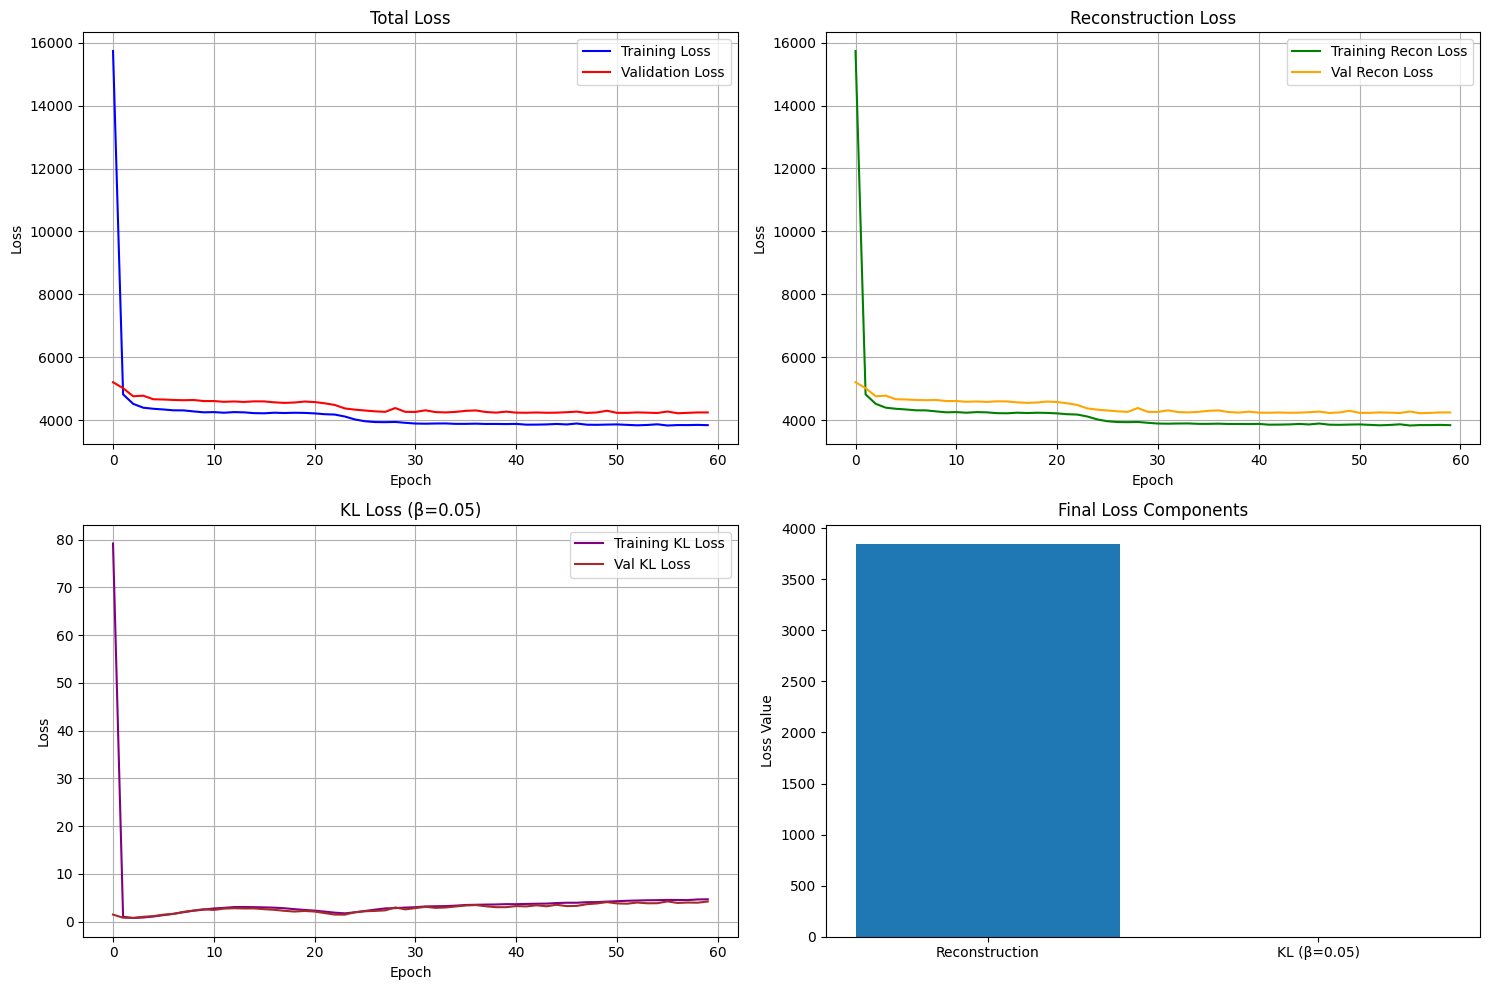


📊 Loss Analysis:
   • Final reconstruction loss: 3841.43
   • Final KL loss: 4.65
   • Final weighted KL loss (β×KL): 0.23
   • Reconstruction vs KL ratio: 16528.84


In [73]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot total loss
axes[0,0].plot(history.history['loss'], label='Training Loss', color='blue')
axes[0,0].plot(history.history['val_loss'], label='Validation Loss', color='red')
axes[0,0].set_title('Total Loss')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()
axes[0,0].grid(True)

# Plot reconstruction loss
axes[0,1].plot(history.history['reconstruction_loss'], label='Training Recon Loss', color='green')
axes[0,1].plot(history.history['val_reconstruction_loss'], label='Val Recon Loss', color='orange')
axes[0,1].set_title('Reconstruction Loss')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Loss')
axes[0,1].legend()
axes[0,1].grid(True)

# Plot KL loss
axes[1,0].plot(history.history['kl_loss'], label='Training KL Loss', color='purple')
axes[1,0].plot(history.history['val_kl_loss'], label='Val KL Loss', color='brown')
axes[1,0].set_title(f'KL Loss (β={beta})')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Loss')
axes[1,0].legend()
axes[1,0].grid(True)

# Plot loss ratio
recon_final = history.history['reconstruction_loss'][-1]
kl_final = history.history['kl_loss'][-1]
axes[1,1].bar(['Reconstruction', f'KL (β={beta})'], [recon_final, beta * kl_final])
axes[1,1].set_title('Final Loss Components')
axes[1,1].set_ylabel('Loss Value')

plt.tight_layout()
plt.show()

print(f"\n📊 Loss Analysis:")
print(f"   • Final reconstruction loss: {recon_final:.2f}")
print(f"   • Final KL loss: {kl_final:.2f}")
print(f"   • Final weighted KL loss (β×KL): {beta * kl_final:.2f}")
print(f"   • Reconstruction vs KL ratio: {recon_final/(beta * kl_final):.2f}")

In [74]:
#@title 6️⃣ FIXED Similarity Analysis with Multiple Metrics
# Get embeddings using z_mean (more stable for similarity)
latent_ref = encoder(np.expand_dims(ref_img, 0))[0].numpy().reshape(-1)
latent_draws = encoder.predict(x_imgs, batch_size=batch_size)[0].reshape(len(x_imgs), -1)

# Multiple distance metrics for comparison
euclidean_dists = np.linalg.norm(latent_draws - latent_ref, axis=1)
cosine_sims = np.array([
    np.dot(latent_ref, draw) / (np.linalg.norm(latent_ref) * np.linalg.norm(draw))
    for draw in latent_draws
])
cosine_dists = 1 - cosine_sims

# Manhattan distance
manhattan_dists = np.sum(np.abs(latent_draws - latent_ref), axis=1)

# Primary ranking: Euclidean distance
order = np.argsort(euclidean_dists)
sorted_paths = [drawing_paths[i] for i in order]
sorted_dists = euclidean_dists[order]

print("🎯 FIXED SIMILARITY RESULTS:")
print("=" * 50)
print("🏆 Top 10 Most Similar Shapes (Euclidean Distance):")
for i, (path, dist) in enumerate(zip(sorted_paths[:10], sorted_dists[:10])):
    print(f"{i+1:2d}. {path.name:<15} | Distance: {dist:.4f}")

print(f"\n📊 Distance Statistics:")
print(f"Mean: {np.mean(euclidean_dists):.4f}")
print(f"Std:  {np.std(euclidean_dists):.4f}")
print(f"Min:  {np.min(euclidean_dists):.4f}")
print(f"Max:  {np.max(euclidean_dists):.4f}")
print(f"Range: {np.max(euclidean_dists) - np.min(euclidean_dists):.4f}")

# Check correlation between distance metrics
from scipy.stats import spearmanr
corr_euc_cos = spearmanr(euclidean_dists, cosine_dists)[0]
print(f"\n🔍 Euclidean vs Cosine correlation: {corr_euc_cos:.3f}")
if corr_euc_cos > 0.8:
    print("✅ Strong metric agreement - reliable similarity!")
else:
    print("⚠️  Metrics disagree - check results carefully")

# Store distances for global variable access
dists = euclidean_dists

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
🎯 FIXED SIMILARITY RESULTS:
🏆 Top 10 Most Similar Shapes (Euclidean Distance):
 1. 7602.png        | Distance: 0.0377
 2. 10899.png       | Distance: 0.0443
 3. 10988.png       | Distance: 0.0645
 4. 10878.png       | Distance: 0.0686
 5. 10856.png       | Distance: 0.0714
 6. 11076.png       | Distance: 0.0986
 7. 10225.png       | Distance: 0.1229
 8. 10964.png       | Distance: 0.1238
 9. 7637.png        | Distance: 0.1244
10. 10969.png       | Distance: 0.1315

📊 Distance Statistics:
Mean: 6.0964
Std:  3.2566
Min:  0.0377
Max:  14.0579
Range: 14.0202

🔍 Euclidean vs Cosine correlation: 1.000
✅ Strong metric agreement - reliable similarity!


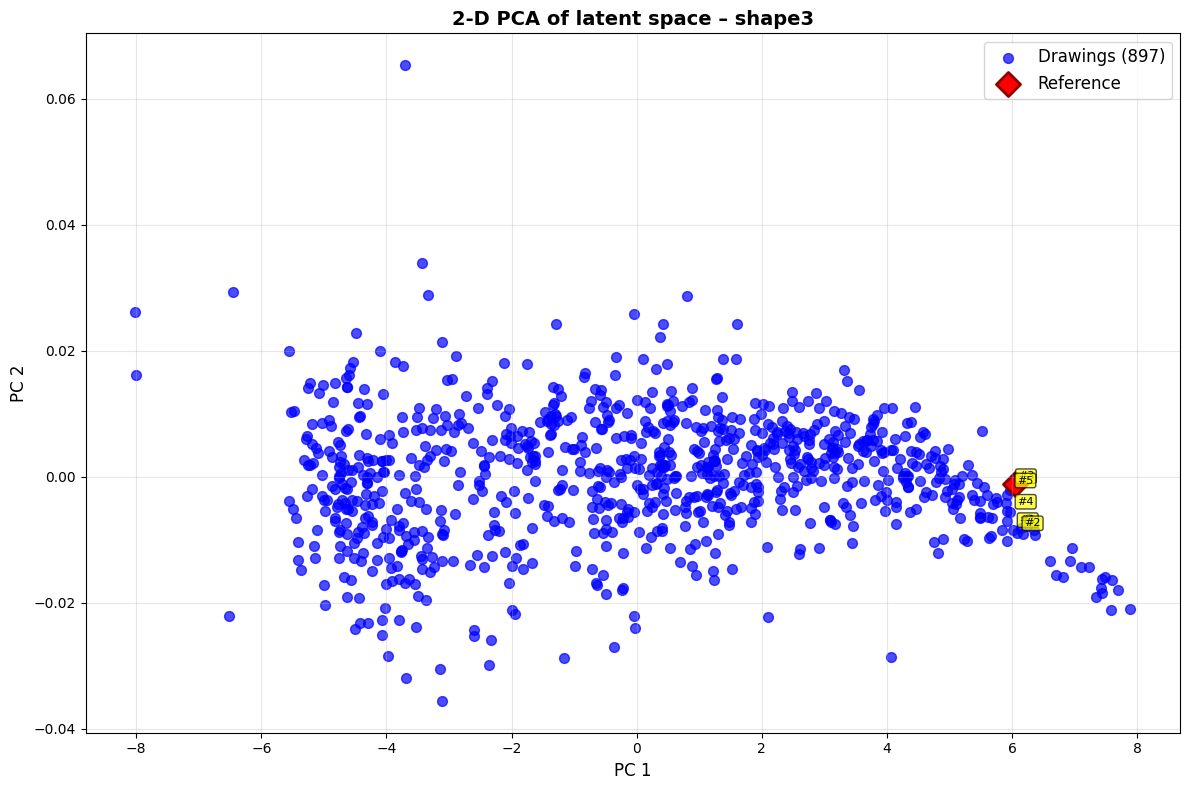

🖼️ IMAGE BROWSER:
Reference Image:


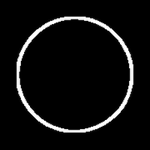


🎯 Top 10 Most Similar Drawings (out of 897):

#1: 7602.png (Distance: 0.0377)


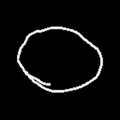


#2: 10899.png (Distance: 0.0443)


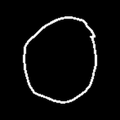


#3: 10988.png (Distance: 0.0645)


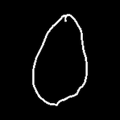


#4: 10878.png (Distance: 0.0686)


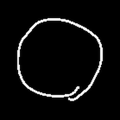


#5: 10856.png (Distance: 0.0714)


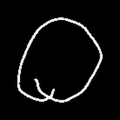


#6: 11076.png (Distance: 0.0986)


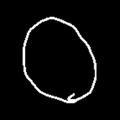


#7: 10225.png (Distance: 0.1229)


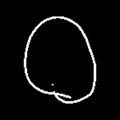


#8: 10964.png (Distance: 0.1238)


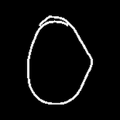


#9: 7637.png (Distance: 0.1244)


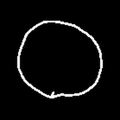


#10: 10969.png (Distance: 0.1315)


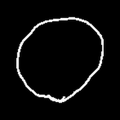


📈 SIMILARITY STATISTICS:
Mean distance: 6.0964
Std distance: 3.2566
Min distance: 0.0377
Max distance: 14.0579
Median distance: 5.9074


In [75]:
#@title 7
# Simple matplotlib version (always works in Colab)
if plot_latent_2D:
    import matplotlib.pyplot as plt
    from sklearn.decomposition import PCA
    from IPython.display import display

    # ---------- reduce to 2‑D ----------
    all_lat = np.vstack([latent_ref.reshape(1, -1), latent_draws])
    lat2    = PCA(n_components=2).fit_transform(all_lat)
    xs, ys  = lat2[:, 0], lat2[:, 1]

    # Create matplotlib plot
    plt.figure(figsize=(12, 8))

    # Plot drawings
    plt.scatter(xs[1:], ys[1:], c='blue', s=50, alpha=0.7, label=f'Drawings ({len(drawing_paths)})')

    # Plot reference
    plt.scatter(xs[0], ys[0], c='red', s=150, marker='D', label='Reference', edgecolors='darkred', linewidth=2)

    # Customize plot
    plt.xlabel('PC 1', fontsize=12)
    plt.ylabel('PC 2', fontsize=12)
    plt.title(f'2-D PCA of latent space – {shape_folder}', fontsize=14, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)

    # Add some annotations for closest points
    closest_indices = np.argsort(dists)[:5]
    for i, idx in enumerate(closest_indices):
        plt.annotate(f'#{i+1}',
                    (xs[idx+1], ys[idx+1]),
                    xytext=(5, 5),
                    textcoords='offset points',
                    fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.7))

    plt.tight_layout()
    plt.show()

    # Create a simple image browser
    print("🖼️ IMAGE BROWSER:")
    print("Reference Image:")
    ref_img_pil = Image.open(ref_path).convert("RGB").resize((150, 150))
    display(ref_img_pil)

    print(f"\n🎯 Top 10 Most Similar Drawings (out of {len(drawing_paths)}):")
    for i, (path, dist) in enumerate(zip(sorted_paths[:10], sorted_dists[:10])):
        print(f"\n#{i+1}: {path.name} (Distance: {dist:.4f})")
        img_pil = Image.open(path).convert("RGB").resize((120, 120))
        display(img_pil)

    # Show some statistics
    print(f"\n📈 SIMILARITY STATISTICS:")
    print(f"Mean distance: {np.mean(dists):.4f}")
    print(f"Std distance: {np.std(dists):.4f}")
    print(f"Min distance: {np.min(dists):.4f}")
    print(f"Max distance: {np.max(dists):.4f}")
    print(f"Median distance: {np.median(dists):.4f}")

▶ HTML gallery written to: /content/drive/MyDrive/shapes/shape3/shape3_vae_similarity.html



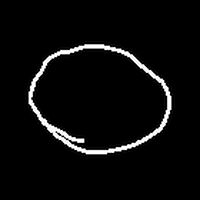
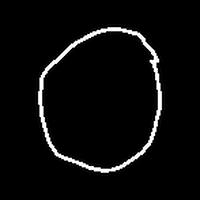
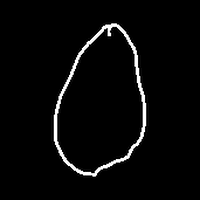
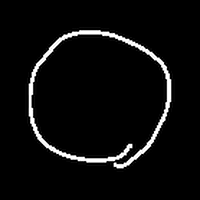
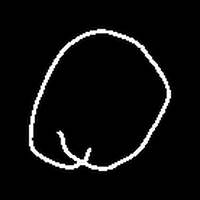
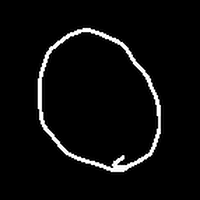
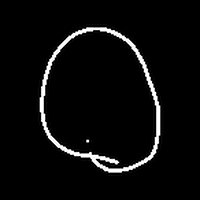
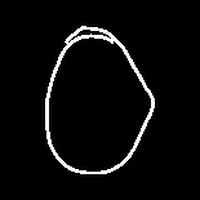
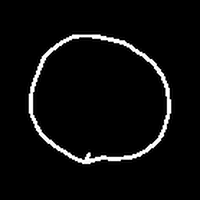
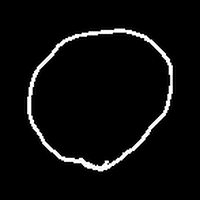
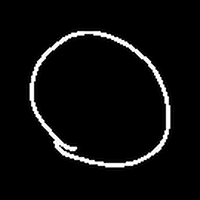
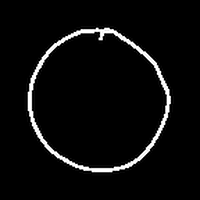
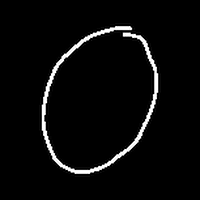
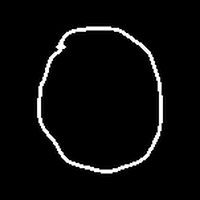
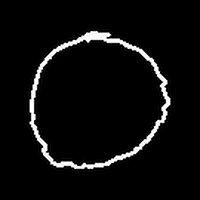
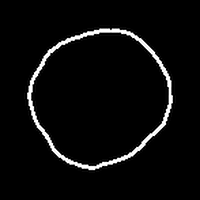
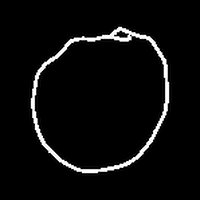
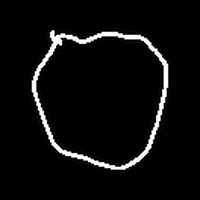
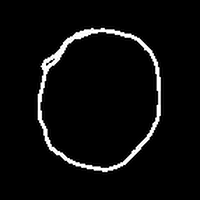
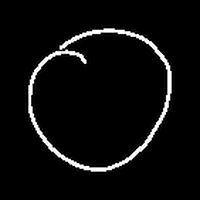
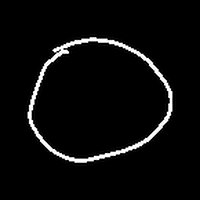
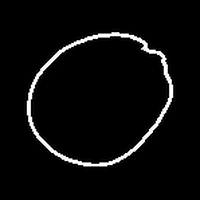
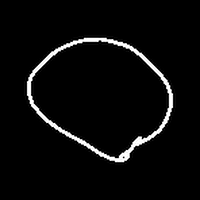
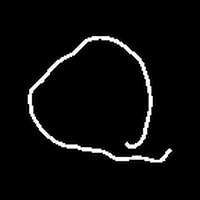
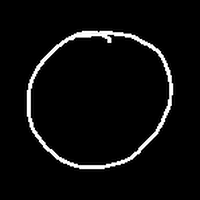
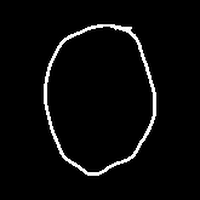
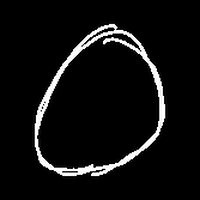
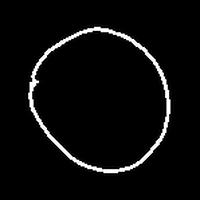

In [76]:

#@title 8️⃣ Create ordered HTML gallery (10 images per row)
html_rows = []
for i, (p,d) in enumerate(zip(sorted_paths, sorted_dists)):
    if i % 10 == 0:
        html_rows.append("<tr>")
    with open(p,'rb') as f: b64 = base64.b64encode(f.read()).decode()
    html_rows.append(
        f"<td style='text-align:center;font-size:10px'>"
        f"<img src='data:image/png;base64,{b64}' width='96'><br>"
        f"{p.name}<br>dist={d:.4f}</td>"
    )
    if i % 10 == 9:
        html_rows.append("</tr>")
if not html_rows[-1].startswith("</tr>"):
    html_rows.append("</tr>")

html_page = f"""
<html><head><meta charset='utf-8'>
<title>{shape_folder} – similarity</title></head>
<body>
<h2>Similarity ranking – {shape_folder}</h2>
<table border=0 cellspacing=4 cellpadding=4>
{''.join(html_rows)}
</table></body></html>
"""

out_path = shape_path / f"{shape_folder}_vae_similarity.html"
with open(out_path,"w") as f: f.write(html_page)
print("▶ HTML gallery written to:", out_path)

display(HTML("<h4>Preview first 30 entries</h4>"+''.join(html_rows[:33])))



1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


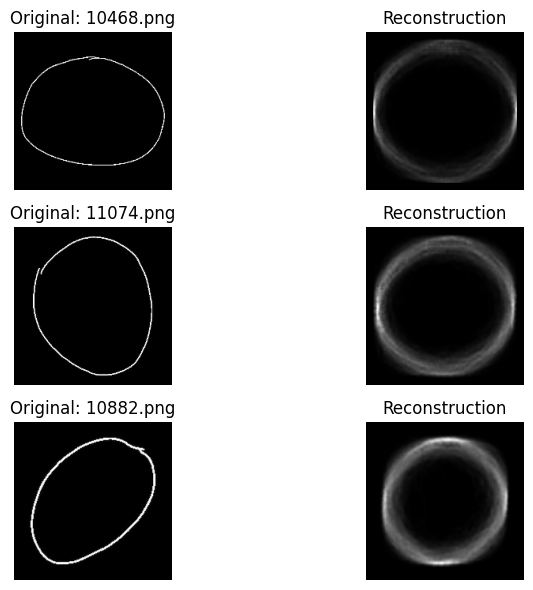

In [77]:
#@title 9️⃣ Reconstruction demo – 3 random drawings
sample_idx = np.random.choice(len(drawing_paths), 3, replace=False)
recons = vae.predict(x_imgs[sample_idx], batch_size=3)

import matplotlib.pyplot as plt
plt.figure(figsize=(9,6))
for i, idx in enumerate(sample_idx):
    # original
    plt.subplot(3,2,2*i+1)
    plt.imshow(x_imgs[idx].squeeze(), cmap='gray')
    plt.axis('off'); plt.title(f"Original: {drawing_paths[idx].name}")
    # reconstruction
    plt.subplot(3,2,2*i+2)
    plt.imshow(recons[i].squeeze(), cmap='gray')
    plt.axis('off'); plt.title("Reconstruction")
plt.tight_layout(); plt.show()
